# Damage calculation and model validation against Assuralia data

In [1]:
#Load libraries
import importlib
import pandas as pd
import xarray as xr
import numpy as np
import datetime as dt
from numpy import nan
from constants import *
import sys
import warnings
import math
import os
import cftime
from glob import glob
from timeit import default_timer as timer

In [29]:
#Colours
blue_dark = "#1f4e79"
blue_main = "#2a6f97"
grey = "#6c757d"
blue_light = "#1f77b4"
blue_very_light = "#74c0fc"


## Load and prepare hazard data

In [30]:
import xarray as xr
import pandas as pd

#Read all ERA5 hazard documents
ds2000_2003 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/wind_gust_00_03')
ds2004_2007 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/wind_gust_04_07')
ds2008_2011 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/wind_gust_08_11')
ds2012_2014 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/wind_gust_12_14')
BE_2015 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/2015/data_stream-oper_stepType-max.nc')
BE_2016 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/2016/data_stream-oper_stepType-max.nc')
BE_2017 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/2017/data_stream-oper_stepType-max.nc')
BE_2018 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/2018/data_stream-oper_stepType-max.nc')
BE_2019 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/2019/data_stream-oper_stepType-max.nc')
BE_2020 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/2020/data_stream-oper_stepType-max.nc')
BE_2021 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/2021/data_stream-oper_stepType-max.nc')
BE_2022 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/2022/data_stream-oper_stepType-max.nc')
BE_2023 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/2023/data_stream-oper_stepType-max.nc')
BE_2024 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/2024/data_stream-oper_stepType-max.nc')

ds_combined_BE = xr.concat([ds2000_2003, ds2004_2007, ds2008_2011, ds2012_2014, BE_2015, BE_2016, BE_2017, BE_2018, BE_2019, BE_2020, BE_2021, BE_2022, BE_2023, BE_2024], dim="valid_time")

era_df = ds_combined_BE.to_dataframe().reset_index()
era_df

era_df

,valid_time,latitude,longitude,fg10,number,expver
0,2000-01-01 00:00:00,5.150000e+01,2.500000e+00,9.744840e+00,0,0001
1,2000-01-01 00:00:00,5.150000e+01,2.750000e+00,9.196988e+00,0,0001
2,2000-01-01 00:00:00,5.150000e+01,3.000000e+00,8.672574e+00,0,0001
3,2000-01-01 00:00:00,5.150000e+01,3.250000e+00,7.343472e+00,0,0001
4,2000-01-01 00:00:00,5.150000e+01,3.500000e+00,6.813199e+00,0,0001
...,...,...,...,...,...,...
15748987,2024-12-31 23:00:00,4.950000e+01,5.250000e+00,1.052510e+01,0,0001
15748988,2024-12-31 23:00:00,4.950000e+01,5.500000e+00,1.052803e+01,0,0001
15748989,2024-12-31 23:00:00,4.950000e+01,5.750000e+00,1.032881e+01,0,0001
15748990,2024-12-31 23:00:00,4.950000e+01,6.000000e+00,9.947950e+00,0,0001


## Load and prepare exposure data

In [5]:
##Import different packages
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import copy as cp
import pandas as pd
from scipy import sparse
import cartopy.crs as ccrs
from timeit import default_timer as timer
from os import mkdir, remove, rmdir

from climada.engine import Impact, ImpactCalc
from climada.entity import ImpactFunc,ImpactFuncSet

import warnings
warnings.filterwarnings('ignore') #Ignore warnings for making the tutorial's pdf.
warnings.simplefilter('ignore')
import logging
from climada.util.config import LOGGER
LOGGER.setLevel(logging.ERROR) #Ignore CLIMADA warnings for making the tutorial's pdf.

##Load self-written, custom function definitions
from SL_bias_corr import *
from constants import *
from functions_projUncWS import *
idx = pd.IndexSlice

In [6]:
EU_countries = ['Belgium']

#Read metadata and filter
ltpop_info = pd.read_csv('/Users/anne-sophiesimons/Desktop/Climate change projections paper/data/_metadata_countries_v1_2.csv',sep=',')
#Filter the rows where the country is equal to Belgium
ctrs_metadata = ltpop_info[ltpop_info["country_name"].isin(EU_countries)][["country_name","region_id","iso3"]]
#ctrs_regis contains only the region IDs of Belgium. The region ID of Belgium is equal to 56.
ctrs_regids = ctrs_metadata.region_id.tolist()

#All litpop region IDs for Belgium.
BE_regids = ctrs_regids  

##Generate LitPop dataLitpop 
from climada.entity import LitPop

#Define the exponents
m, n = 1, 0.25
#Resolution
res_exp = 30
#Threshold exposure value in USD
exp_thres = 1

#Load LitPop exposure data for every year
exp_BE_2015 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2015)
exp_BE_2016 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2016)
exp_BE_2017 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2017)
exp_BE_2018 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2018)
exp_BE_2019 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2019)
exp_BE_2020 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2020)
exp_BE_2021 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2021)
exp_BE_2022 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2022)
exp_BE_2023 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2023)
exp_BE_2024 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2024)

## Load and prepare vulnerability functions

In [7]:
##First impact function: Schwierz
#Get the standard European storm impact function from CLIMADA (Schwierz et al. 2010)
from climada.entity.impact_funcs import storm_europe

#Load the Schwierz impact function
impFunc_schw = storm_europe.ImpfStormEurope.from_schwierz()

#Properties of the impact function 
impFunc_schw.id = 1 #Unique ID-number for the impact function
impFunc_schw.haz_type = 'WS' #WS is Wind Storm
impFunc_schw.name = 'Sw2010' #Name of the impact function
impFunc_schw.check() #Check if all properties are correctly


In [8]:
##Second impact function: Cubic Excess over Threshold
#Implement impact function cubic excess over threshold from Klawa 2003
#Import the general ImpactFunc class
from climada.entity import ImpactFunc
#Make a new empty impact function
imp_fun_cub = ImpactFunc()
#Set the hazard type and name
imp_fun_cub.haz_type = 'WS'
imp_fun_cub.name = 'CubEOT'
#Provide unit of the hazard (wind) intensity
imp_fun_cub.intensity_unit = 'm/s'
#Define normalised wind intensities (0 to 1)
imp_fun_cub.intensity = np.linspace(0, 1, num=20)
#Define the damage function: damage increases cubically with intensity
imp_fun_cub.mdd = imp_fun_cub.intensity**3
#Add an extreme value: Above the extreme wind intensity then 100% damage
imp_fun_cub.intensity = np.append(imp_fun_cub.intensity, [100])
imp_fun_cub.mdd = np.append(imp_fun_cub.mdd, [1])
#Probability that there is damage is equal to 100% of all intensities
imp_fun_cub.paa = np.ones(imp_fun_cub.intensity.shape)

#Check if the all the attributes are set correctly
imp_fun_cub.id = 2
imp_fun_cub.check()

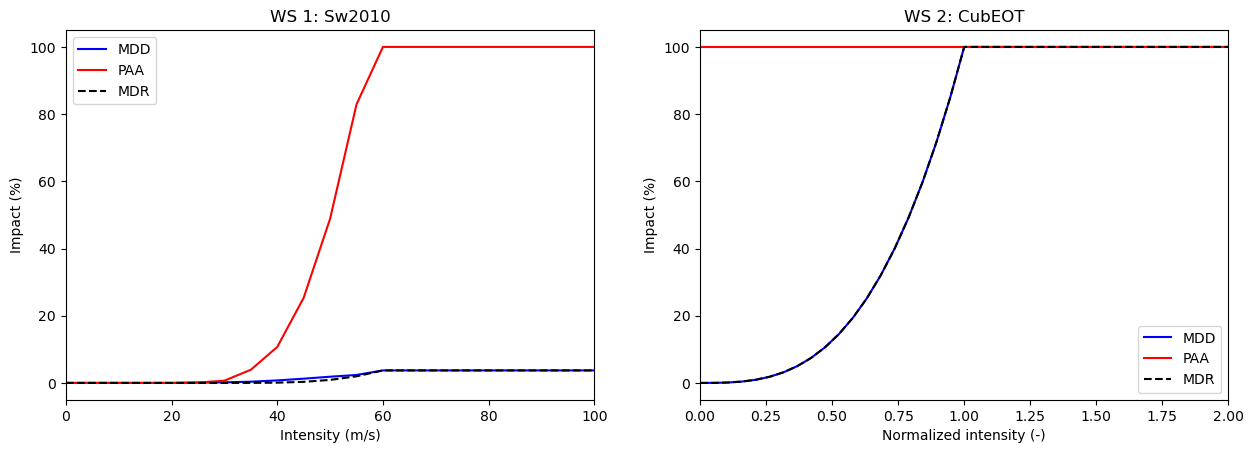

In [9]:
#Generate one impact function set containing all functions
from climada.entity import ImpactFuncSet
#Include the impact functions in the impact function set
#impf_list = [impFunc_schw, imp_fun_cub]
impf_list = [impFunc_schw, imp_fun_cub]

#A list with function names and a dictionary linking names to IDs
impf_namelist = []
impf_dict = {}
#Create an empty impact function set
impf_set = ImpactFuncSet()

#Add each impact function to the set and store its name and ID
for impf in impf_list:
    impfname = impf.name
    impf_namelist.append(impfname)
    impf_dict[impfname] = impf.id
    impf_set.append(impf)
    impf_set.check() #Validate the impact function set

#Plot the impact functions
axs = impf_set.plot()
fig = axs[0].get_figure()
fig.set_figwidth(15) #Adjust the figure width
axs[1].set_xlabel('Normalized intensity (-)') #Set the x-axis label
axs[1].set_xlim((0,2)); #Set the x-axis limits

In [10]:
## Compute correction factor for CubEOT
aai_agg_assuralia = 163798106.66
aai_agg_CubEOT = 231564109000

CubEOT_corr_fact = aai_agg_assuralia /aai_agg_CubEOT
print(CubEOT_corr_fact)

0.0007073553296638037


0.0007073553296638037


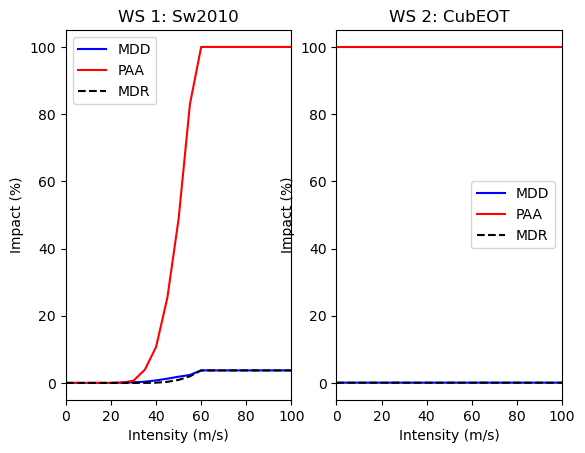

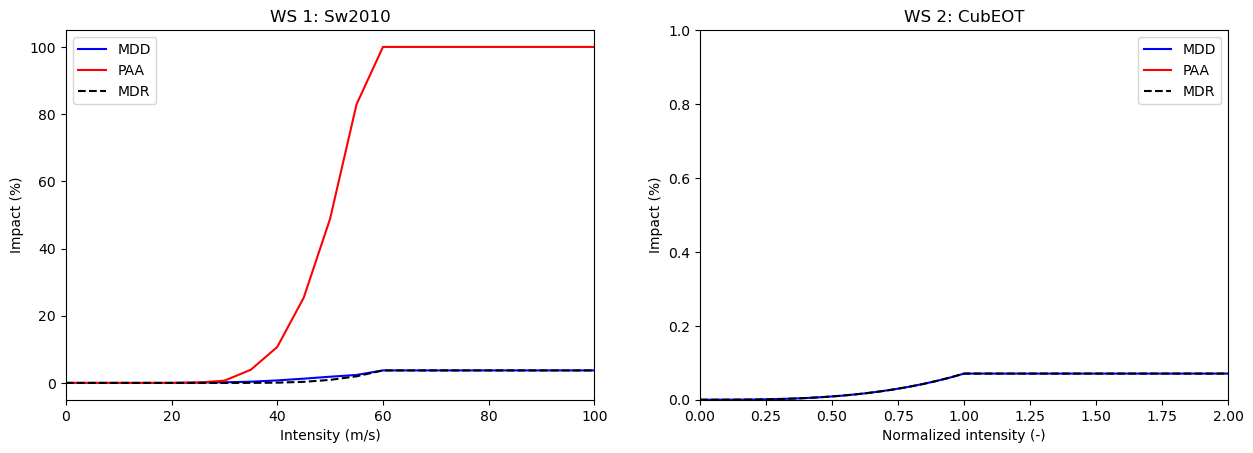

In [11]:
## Compute correction factor for CubEOT
aai_agg_assuralia = 163798106.66
aai_agg_CubEOT = 231564109000

CubEOT_corr_fact = aai_agg_assuralia /aai_agg_CubEOT
print(CubEOT_corr_fact)

#Rescale CubEOT impact function
[impf] = impf_set.get_func(fun_id=2) #get CubEOT
impf_set.remove_func(fun_id=2) #remove CubEOT
impf.mdd *= CubEOT_corr_fact
impf_set.append(impf)
axs = impf_set.plot()
fig = axs[0].get_figure()

axs = impf_set.plot()
fig = axs[0].get_figure()
fig.set_figwidth(15)
axs[1].set_xlabel('Normalized intensity (-)')
axs[1].set_xlim((0,2));
axs[1].set_ylim((0,1));

## Damage Calculation

In [12]:
#Climate model and scenario selection
pastname = 'historical' #Name of historical period
timeres = 'valid_time' #Name of the time dimension of netcdf
eravar = 'fg10' #Name of the wind variable of netcdf ###Verandert van wind_speed naar 10fg

#Impact function setup
impf_dict = impf_dict #Dictionary mapping impact functions names to their ids
impf_set = impf_set #Impact function set
pp_func_dic = pp_func_dic #Dictionary with the preprocessing functions for the impact functions

#Preprocessing parameters
gst_fact = 1 #Gust factor
qt = 0.98 #Quantile threshold for event detection
cut = 1 #Area threshold for event detection
mask_abs = 22.2 #Absolute threshold for damage calculation
regrid = False #Whether to regrid ERA5 data to rg_res; if True then regrid
rg_res = 0.25 #Horizontal regridding in degree

#CLIMADA constants
haz_type = 'WS' #Hazard type: Wind Storm
haz_id = 1 #Hazard ID
dist_th_cst = 300 #Distance treshold in km to assign centroids

In [13]:
#Initiate DataFrame to save results
metrics = ['aai_agg',1,10,15,20, 25, 30] #Impact metrics to be computed, select aai_agg for Average Annual Damage, and integers for rps

iterables = [metrics,impf_dict.keys()]
col_idx1 = pd.MultiIndex.from_product(iterables,names=["metric","Impf"])
res_df = pd.DataFrame(columns=metrics,index=impf_dict.keys())

In [14]:
#Main Calculation
import numpy as np
import xarray as xr
import copy as cp
from timeit import default_timer as timer

from climada.engine import Impact, ImpactCalc

#Options
savehaz = False
saveimpmat = True
saveimpcsv = True
savestats = True

#Load ERA5 datasets
BE_2015 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/2015/data_stream-oper_stepType-max.nc')
BE_2016 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/2016/data_stream-oper_stepType-max.nc')
BE_2017 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/2017/data_stream-oper_stepType-max.nc')
BE_2018 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/2018/data_stream-oper_stepType-max.nc')
BE_2019 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/2019/data_stream-oper_stepType-max.nc')
BE_2020 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/2020/data_stream-oper_stepType-max.nc')
BE_2021 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/2021/data_stream-oper_stepType-max.nc')
BE_2022 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/2022/data_stream-oper_stepType-max.nc')
BE_2023 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/2023/data_stream-oper_stepType-max.nc')
BE_2024 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/2024/data_stream-oper_stepType-max.nc')

#Store datasets per year
era_data = {
    2015: BE_2015,
    2016: BE_2016,
    2017: BE_2017,
    2018: BE_2018,
    2019: BE_2019,
    2020: BE_2020,
    2021: BE_2021,
    2022: BE_2022,
    2023: BE_2023,
    2024: BE_2024
}

#Store exposure per year
exp_data = {
    2015: exp_BE_2015,
    2016: exp_BE_2016,
    2017: exp_BE_2017,
    2018: exp_BE_2018,
    2019: exp_BE_2019,
    2020: exp_BE_2020,
    2021: exp_BE_2021,
    2022: exp_BE_2022,
    2023: exp_BE_2023,
    2024: exp_BE_2024
}

#Belgium spatial bounds
min_lat, max_lat = 49.5, 51.5
min_lon, max_lon = 2.5, 6.4

#Return periods
return_periods = np.linspace(1, 100, num=50)

#Storage
impacts = {}
efc_dict = {}

#Main loop

for year in range(2015, 2025):

    print(f"Processing year {year}")

    #Initialize per year dictionaries
    impacts[year] = {}
    efc_dict[year] = {}

    era_ds = era_data[year]
    exp_emdat = exp_data[year]

    #Rename wind variable
    era_ds = era_ds.rename_vars({eravar: pastname})

    #Resolution
    latres, lonres = get_lat_lon_res(era_ds)

    #Apply gust factor
    gust_era = gst_fact * era_ds

    #Regrid if needed
    if regrid:
        latout = np.arange(min_lat, max_lat + rg_res, rg_res)
        lonout = np.arange(min_lon, max_lon + rg_res, rg_res)

        gust_era = gust_era.interp(
            latitude=latout,
            longitude=lonout,
            method='linear',
            kwargs={"fill_value": 'extrapolate'}
        )

    #Loop over impact functions

    for impfname, if_id in impf_dict.items():

        print(f"Impact function: {impfname}")

        preprocess_func = pp_func_dic[impfname]

        #Preprocess wind data
        gust_pp = preprocess_func(
            gust_era,
            qt,
            mask_abs=mask_abs,
            cutarea=cut,
            timeres="valid_time",
            pastname='historical',
            futname='historical',
            stack=False
        )

        #Create hazard
        haz = set_centroids(
            gust_pp,
            stack=False,
            timeres="valid_time",
            plot=False
        )

        #Copy exposure
        exp_sel = cp.deepcopy(exp_emdat)

        #Assign impact function
        exp_sel.gdf.rename(columns={"impf_": "impf_" + haz_type}, inplace=True)
        exp_sel.gdf["impf_" + haz_type] = if_id

        #Assign centroids
        exp_sel.assign_centroids(haz, distance='euclidean', threshold=300)
        exp_sel.check()

        #Compute impact
        start_time = timer()

        impcalc = ImpactCalc(exp_sel, impf_set, haz)
        imp = impcalc.impact(
            save_mat=saveimpmat,
            assign_centroids=False
        )

        elapsed_time = timer() - start_time
        print(f"Calculation time: {elapsed_time:.2f} sec")

        #Store results

        #Store impact per impact function
        impacts[year][impfname] = imp

        #EFC per impact function
        efc = imp.calc_freq_curve(return_per=return_periods)
        efc_dict[year][impfname] = efc

        #Statistics
        if savestats:
            for imet, met in enumerate(metrics):

                if met == 'aai_agg':
                    impmet = imp.at_event.sum()
                else:
                    impmet = imp.calc_freq_curve(return_per=met).impact

                res_df.loc[f"{impfname}_{year}", met] = impmet

    #Post-process year

    res_df = res_df.astype(np.float64)

    print(res_df)

    #Quick structure check
    print(impacts[2015].keys())

Processing year 2015
Impact function: Sw2010
Calculation time: 0.15 sec
Impact function: CubEOT
Calculation time: 0.12 sec
                  aai_agg             1            10            15  \
Sw2010                NaN           NaN           NaN           NaN   
CubEOT                NaN           NaN           NaN           NaN   
Sw2010_2015  4.086238e+07  4.503493e+06  4.503493e+06  4.503493e+06   
CubEOT_2015  5.075404e+07  6.982544e+06  6.982544e+06  6.982544e+06   

                       20            25            30  
Sw2010                NaN           NaN           NaN  
CubEOT                NaN           NaN           NaN  
Sw2010_2015  4.503493e+06  4.503493e+06  4.503493e+06  
CubEOT_2015  6.982544e+06  6.982544e+06  6.982544e+06  
dict_keys(['Sw2010', 'CubEOT'])
Processing year 2016
Impact function: Sw2010
Calculation time: 0.15 sec
Impact function: CubEOT
Calculation time: 0.14 sec
                  aai_agg             1            10            15  \
Sw2010         

### At national level

In [80]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np

os.environ["SHAPE_RESTORE_SHX"] = "YES"

#Load shapefile
provinces = gpd.read_file('/Users/anne-sophiesimons/Documents/Data thesis/gadm41_BEL_0.shp')
provinces = provinces.set_crs(epsg=4326)

#Table to save impact per year and impact function
impact_all_years = pd.DataFrame()

years = list(range(2015, 2025))

#Loop over all years
for i, year in enumerate(years):

    print(f"Processing maps for {year}")

    #Loop over impact functions
    for impfname, imp in impacts[year].items():

        print(f"  Impact function: {impfname}")

        #Exposure points
        points = exp_data[year].gdf.copy()
        points = points.set_crs(epsg=4326)

        #Add impact per impact function impact
        points['impact'] = imp.eai_exp

        #Add coordinates
        points['longitude'] = points.geometry.x
        points['latitude'] = points.geometry.y

        #Spatial join 
        points_with_polygon = gpd.sjoin(points, provinces, how='left', predicate='within')

        #Impact per province
        impact_by_polygon = (
            points_with_polygon
            .groupby('index_right')['impact']
            .sum()
            .reset_index()
        )

        #Merge with shapefile
        provinces_merged = provinces.merge(
            impact_by_polygon,
            left_index=True,
            right_on='index_right',
            how='left'
        )

        #Save in table
        impact_all_years[f'{year}_{impfname}'] = provinces_merged['impact']

#Formatting tables
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 170)
pd.set_option('display.float_format', '{:.6e}'.format)

#Index names
names = {
    0: 'België'
}

impact_all_years.index = impact_all_years.index.map(names)

print(impact_all_years)

Processing maps for 2015
  Impact function: Sw2010
  Impact function: CubEOT
Processing maps for 2016
  Impact function: Sw2010
  Impact function: CubEOT
Processing maps for 2017
  Impact function: Sw2010
  Impact function: CubEOT
Processing maps for 2018
  Impact function: Sw2010
  Impact function: CubEOT
Processing maps for 2019
  Impact function: Sw2010
  Impact function: CubEOT
Processing maps for 2020
  Impact function: Sw2010
  Impact function: CubEOT
Processing maps for 2021
  Impact function: Sw2010
  Impact function: CubEOT
Processing maps for 2022
  Impact function: Sw2010
  Impact function: CubEOT
Processing maps for 2023
  Impact function: Sw2010
  Impact function: CubEOT
Processing maps for 2024
  Impact function: Sw2010
  Impact function: CubEOT
        2015_Sw2010  2015_CubEOT  2016_Sw2010  2016_CubEOT  2017_Sw2010  2017_CubEOT  2018_Sw2010  2018_CubEOT  2019_Sw2010  2019_CubEOT  2020_Sw2010  2020_CubEOT  \
België 4.051452e+07 5.036115e+07 4.469757e+07 5.722778e+07 2.169

In [81]:
import pandas as pd

#Load Assuralia data on national level
Assuralia = pd.read_excel(
    '/Users/anne-sophiesimons/Documents/Data thesis/Schade_België.xlsx'
)


assuralia_long = Assuralia.melt(
    id_vars=['Jaar'],
    var_name='België',
    value_name='impact'
)

assuralia_table = assuralia_long.pivot(
    index='België',
    columns='Jaar',
    values='impact'
)

#Change column names
assuralia_table.columns = [f'impact_{year}' for year in assuralia_table.columns]

#Sort provinces
assuralia_table = assuralia_table.sort_index()

#Format values to scientic notation with 6 decimals
assuralia_table_formatted = assuralia_table.applymap(
    lambda x: f"{x:.6e}" if pd.notnull(x) else "NaN"
)

import pandas as pd

#Show all columns
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', 150)        
pd.set_option('display.float_format', '{:.6e}'.format)  

print(assuralia_table_formatted)

         impact_2015   impact_2016   impact_2017   impact_2018   impact_2019   impact_2020   impact_2021   impact_2022   impact_2023   impact_2024
België                                                                                                                                            
België  5.349838e+07  4.890108e+07  4.652760e+07  1.528856e+08  2.360354e+08  2.981430e+08  7.296194e+07  5.806740e+08  1.021954e+08  4.615881e+07


In [82]:
import pandas as pd

#Correct the index
impact_model = impact_all_years.copy()
impact_model.index.name = "België"

impact_obs = assuralia_table.copy()
impact_obs.index.name = "België"

#Empty table
comparison_table = pd.DataFrame(index=impact_model.index)

years = range(2015, 2025)

#Get impact functions
impf_list = sorted(list(set(
    col.split('_')[1] for col in impact_model.columns
)))

#Loop over all years and impact
for year in years:
    for impfname in impf_list:

        col_name = f'{year}_{impfname}'

        #Modelled damage per impact function
        if col_name in impact_model.columns:
            comparison_table[f'model_{col_name}'] = impact_model[col_name]
        else:
            comparison_table[f'model_{col_name}'] = None

    #Observed damage
    if f'impact_{year}' in impact_obs.columns:
        comparison_table[f'obs_{year}'] = impact_obs[f'impact_{year}']
    else:
        comparison_table[f'obs_{year}'] = None


pd.set_option('display.max_columns', None)
pd.set_option('display.width', 170)
pd.set_option('display.float_format', '{:.6e}'.format)

print(comparison_table)

        model_2015_CubEOT  model_2015_Sw2010     obs_2015  model_2016_CubEOT  model_2016_Sw2010     obs_2016  model_2017_CubEOT  model_2017_Sw2010     obs_2017  \
België                                                                                                                                                            
België       5.036115e+07       4.051452e+07 5.349838e+07       5.722778e+07       4.469757e+07 4.890108e+07       2.349847e+07       2.169250e+07 4.652760e+07   

        model_2018_CubEOT  model_2018_Sw2010     obs_2018  model_2019_CubEOT  model_2019_Sw2010     obs_2019  model_2020_CubEOT  model_2020_Sw2010     obs_2020  \
België                                                                                                                                                            
België       1.411482e+08       7.968360e+07 1.528856e+08       4.861541e+07       3.656564e+07 2.360354e+08       4.761447e+08       2.865992e+08 2.981430e+08   

        model_2021_C

In [83]:
#A clean table for to show the differences between modelled and observed damages
table_clean = pd.DataFrame(index=years, columns=["CubEOT", "Sw2010", "Observed"])

for year in years:
    for impf in impf_list:
        col = f"{year}_{impf}"
        if col in impact_model.columns:
            table_clean.loc[year, impf] = impact_model.loc["België", col]

    obs_col = f"impact_{year}"
    if obs_col in impact_obs.columns:
        table_clean.loc[year, "Observed"] = impact_obs.loc["België", obs_col]

print(table_clean)

           CubEOT       Sw2010     Observed
2015 5.036115e+07 4.051452e+07 5.349838e+07
2016 5.722778e+07 4.469757e+07 4.890108e+07
2017 2.349847e+07 2.169250e+07 4.652760e+07
2018 1.411482e+08 7.968360e+07 1.528856e+08
2019 4.861541e+07 3.656564e+07 2.360354e+08
2020 4.761447e+08 2.865992e+08 2.981430e+08
2021 1.346241e+08 8.936546e+07 7.296194e+07
2022 3.556247e+08 1.994881e+08 5.806740e+08
2023 2.550781e+08 1.747255e+08 1.021954e+08
2024 1.152021e+08 6.845999e+07 4.615881e+07


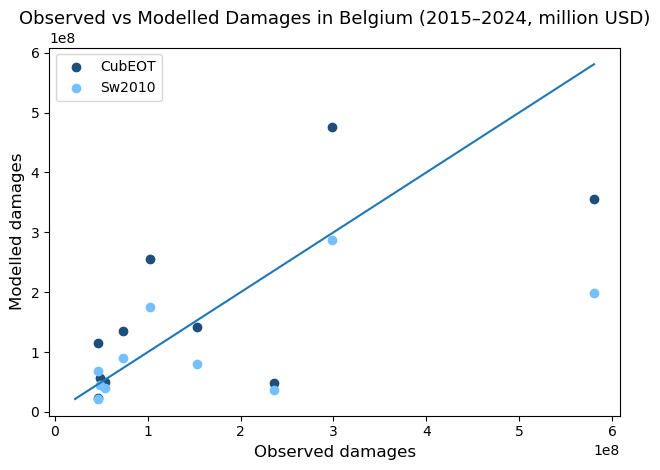

In [84]:
#Make a scatter plot
import matplotlib.pyplot as plt

#Data from the table
observed = table_clean["Observed"].astype(float)
cubEOT = table_clean["CubEOT"].astype(float)
sw2010 = table_clean["Sw2010"].astype(float)

plt.figure()

#Scatter points
plt.scatter(observed, cubEOT, label="CubEOT", color = blue_dark)
plt.scatter(observed, sw2010, label="Sw2010", color = blue_very_light)

#Identify line
min_val = min(observed.min(), cubEOT.min(), sw2010.min())
max_val = max(observed.max(), cubEOT.max(), sw2010.max())
plt.plot([min_val, max_val], [min_val, max_val])

#Labels and legends
plt.xlabel("Observed damages", fontsize=12)
plt.ylabel("Modelled damages", fontsize=12)
plt.legend()

plt.title("Observed vs Modelled Damages in Belgium (2015–2024, million USD)", fontsize = 13)

plt.tight_layout()

plt.savefig("/Users/anne-sophiesimons/Documents/Data thesis/scatter_obs_mod", dpi=300)
plt.show()

In [20]:
#Get metrcis
import numpy as np
import pandas as pd

years = range(2015, 2025)

#Get impact functions
impf_list = sorted(list(set(
    col.split('_')[2] for col in comparison_table.columns if col.startswith("model_")
)))

results = []

for region in comparison_table.index:

    for impfname in impf_list:

        #Modelled data per impact function
        model = pd.to_numeric(
            [comparison_table.loc[region, f"model_{year}_{impfname}"] for year in years],
            errors="coerce"
        )

        #Observed data  OBS
        obs = pd.to_numeric(
            [comparison_table.loc[region, f"obs_{year}"] for year in years],
            errors="coerce"
        )

        model = np.array(model, dtype=float)
        obs = np.array(obs, dtype=float)

        mask = ~np.isnan(model) & ~np.isnan(obs) & (obs != 0)

        if np.sum(mask) == 0:
            continue

        mae = np.mean(np.abs(model[mask] - obs[mask]))
        rmse = np.sqrt(np.mean((model[mask] - obs[mask])**2))
        bias = np.mean(model[mask] - obs[mask])
        mape = np.mean(np.abs((model[mask] - obs[mask]) / obs[mask])) * 100

        #Compute correlation
        if np.std(model[mask]) == 0 or np.std(obs[mask]) == 0:
            corr = np.nan
        else:
            corr = np.corrcoef(model[mask], obs[mask])[0, 1]

        results.append({
            "België": region,
            "impact_function": impfname,
            "MAE": mae,
            "RMSE": rmse,
            "Bias": bias,
            "MAPE (%)": mape,
            "Correlation r": corr,
            "R²": corr**2 if not np.isnan(corr) else np.nan
        })

results_df = pd.DataFrame(results).set_index(["België", "impact_function"])

print(results_df)

                                MAE         RMSE          Bias     MAPE (%)  Correlation r           R²
België impact_function                                                                                 
België CubEOT          9.202896e+07 1.225347e+08  1.954372e+06 6.416170e+01   6.831231e-01 4.666572e-01
       Sw2010          8.186586e+07 1.405036e+08 -5.961889e+07 4.299170e+01   6.299123e-01 3.967895e-01


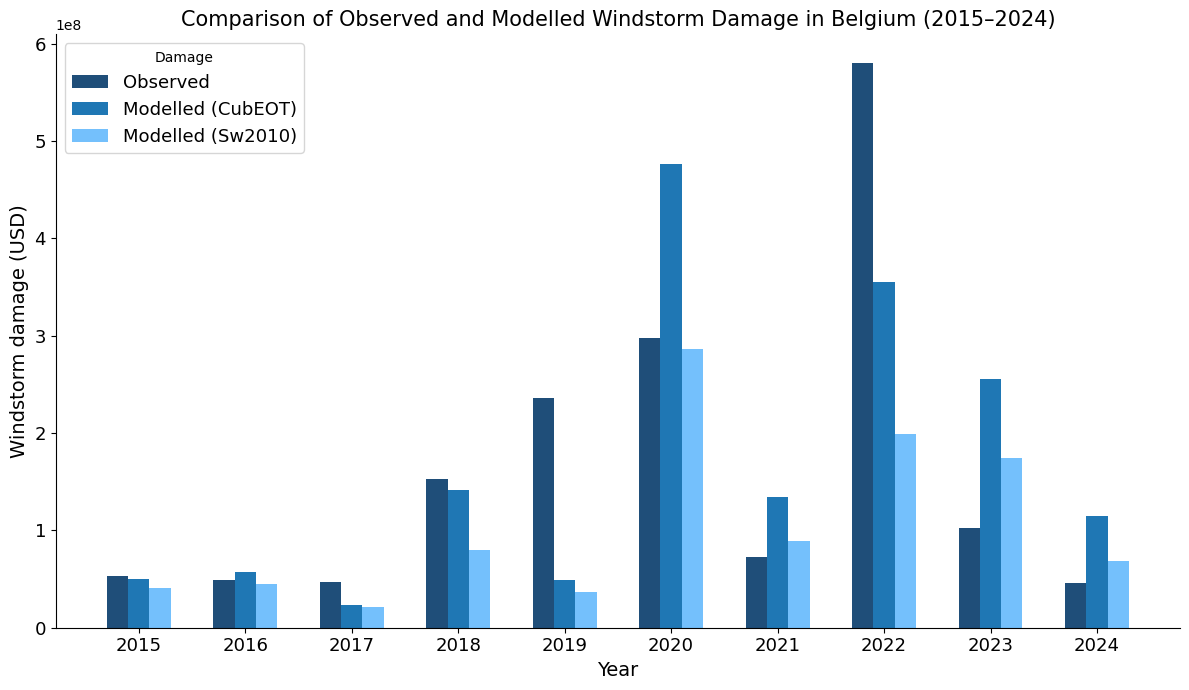

In [88]:
#Figure to compare observed and modelled damage
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

years = list(range(2015, 2025))
België = comparison_table.index

#Get impact function
impf_list = sorted(list(set(
    col.split('_')[2] for col in comparison_table.columns if col.startswith("model_")
)))

#Make a dataFrame
plot_data = []

for land in België:
    for year in years:

        row = {
            "Year": year,
            "België": land,
            "Observed": comparison_table.loc[land, f"obs_{year}"]
        }

        #Add a column per impact function
        for impfname in impf_list:
            row[f"Model_{impfname}"] = comparison_table.loc[land, f"model_{year}_{impfname}"]

        plot_data.append(row)

plot_df = pd.DataFrame(plot_data)

#Make numeric
plot_df["Observed"] = pd.to_numeric(plot_df["Observed"])

for impfname in impf_list:
    plot_df[f"Model_{impfname}"] = pd.to_numeric(plot_df[f"Model_{impfname}"])


plot_df["België"] = pd.Categorical(plot_df["België"], categories=België, ordered=True)

#Plotting
fig, axes = plt.subplots(
    nrows=len(België),
    ncols=1,
    figsize=(12, 7),
    sharex=True
)

if len(België) == 1:
    axes = [axes]

for ax, land in zip(axes, België):

    df = plot_df[plot_df["België"] == land]

    x = np.arange(len(years))
    width = 0.2 

    # Observed
    ax.bar(
    x - width,
    df["Observed"],
    width,
    label="Observed",
    color=blue_dark
    )

#Model impact functions
    colors = [blue_light, blue_very_light]
    #colors = ["#1f77b4", "#74c0fc" ]


    for i, impfname in enumerate(impf_list):
        ax.bar(
        x + i * width,
        df[f"Model_{impfname}"],
        width,
        label=f"Model {impfname}",
        color=colors[i]
        )


    ax.set_ylabel("Windstorm damage (USD)", fontsize = 14)
    ax.set_title("Comparison of Observed and Modelled Windstorm Damage in Belgium (2015–2024)", fontsize = 15)
    ax.set_xticks(x)
    ax.set_xticklabels(years)
    ax.legend(
    ["Observed", "Modelled (CubEOT)", "Modelled (Sw2010)"],
    title="Damage",
    loc="upper left",
    fontsize = 13
)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis='both', labelsize=13)

plt.xlabel("Year", fontsize = 14)
plt.tight_layout()

plt.savefig("/Users/anne-sophiesimons/Documents/Data thesis/nationaal_obsVSmod", dpi=300)
plt.show()

### At regional level

In [89]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np

os.environ["SHAPE_RESTORE_SHX"] = "YES"

#Load shapefile
provinces = gpd.read_file('/Users/anne-sophiesimons/Documents/Data thesis/gadm41_BEL_1.shp')
provinces = provinces.set_crs(epsg=4326)

#Table with impact per year and impact function
impact_all_years = pd.DataFrame()

years = list(range(2015, 2025))

#Loop over all years
for i, year in enumerate(years):

    print(f"Processing maps for {year}")

    #Loop over impact functions 
    for impfname, imp in impacts[year].items():

        print(f"  Impact function: {impfname}")

        #Exposure
        points = exp_data[year].gdf.copy()
        points = points.set_crs(epsg=4326)

        #Add impact
        points['impact'] = imp.eai_exp

        #Add coordinates
        points['longitude'] = points.geometry.x
        points['latitude'] = points.geometry.y

        #Spatial join
        points_with_polygon = gpd.sjoin(points, provinces, how='left', predicate='within')

        #Impact per provincie
        impact_by_polygon = (
            points_with_polygon
            .groupby('index_right')['impact']
            .sum()
            .reset_index()
        )

        #Merge with shapefile
        provinces_merged = provinces.merge(
            impact_by_polygon,
            left_index=True,
            right_on='index_right',
            how='left'
        )

        #Save in table
        impact_all_years[f'{year}_{impfname}'] = provinces_merged['impact']

#Formatting table
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 170)
pd.set_option('display.float_format', '{:.6e}'.format)

#Index names of provinces
names = {
    0: 'Brussels',
    1: 'Flanders',
    2: 'Wallonia'
}

impact_all_years.index = impact_all_years.index.map(names)

print(impact_all_years)

Processing maps for 2015
  Impact function: Sw2010
  Impact function: CubEOT
Processing maps for 2016
  Impact function: Sw2010
  Impact function: CubEOT
Processing maps for 2017
  Impact function: Sw2010
  Impact function: CubEOT
Processing maps for 2018
  Impact function: Sw2010
  Impact function: CubEOT
Processing maps for 2019
  Impact function: Sw2010
  Impact function: CubEOT
Processing maps for 2020
  Impact function: Sw2010
  Impact function: CubEOT
Processing maps for 2021
  Impact function: Sw2010
  Impact function: CubEOT
Processing maps for 2022
  Impact function: Sw2010
  Impact function: CubEOT
Processing maps for 2023
  Impact function: Sw2010
  Impact function: CubEOT
Processing maps for 2024
  Impact function: Sw2010
  Impact function: CubEOT
          2015_Sw2010  2015_CubEOT  2016_Sw2010  2016_CubEOT  2017_Sw2010  2017_CubEOT  2018_Sw2010  2018_CubEOT  2019_Sw2010  2019_CubEOT  2020_Sw2010  2020_CubEOT  \
Brussels 1.254951e+06 1.493286e+06 1.396278e+06 1.560402e+06 4

In [90]:
import pandas as pd

#Load Assuralia data
Assuralia_per_gewest = pd.read_excel(
    '/Users/anne-sophiesimons/Documents/Data thesis/Schade_per_gewest.xlsx'
)

assuralia_long_gewest = Assuralia_per_gewest.melt(
    id_vars=['Jaar'],
    var_name='gewest',
    value_name='impact'
)

assuralia_table_gewest = assuralia_long_gewest.pivot(
    index='gewest',
    columns='Jaar',
    values='impact'
)

#Change names of the columns
assuralia_table_gewest.columns = [f'impact_{year}' for year in assuralia_table_gewest.columns]

#Sort provinces
assuralia_table_gewest = assuralia_table_gewest.sort_index()

#Format values to scientific notation with 6 decimals
assuralia_table_formatted_gewest = assuralia_table_gewest.applymap(
    lambda x: f"{x:.6e}" if pd.notnull(x) else "NaN"
)

import pandas as pd

#Show all columns
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', 150)        
pd.set_option('display.float_format', '{:.6e}'.format) 

print(assuralia_table_formatted_gewest)

           impact_2015   impact_2016   impact_2017   impact_2018   impact_2019   impact_2020   impact_2021   impact_2022   impact_2023   impact_2024
gewest                                                                                                                                              
Brussels  3.337959e+06  2.099850e+06  1.080671e+06  3.657640e+06  5.380766e+06  8.977559e+06  3.923544e+06  1.752121e+07  2.663364e+06  1.570886e+06
Flanders  3.584118e+07  3.432002e+07  3.322128e+07  1.113153e+08  1.900685e+08  1.574491e+08  4.609773e+07  4.165509e+08  6.969508e+07  2.876244e+07
Wallonia  1.431924e+07  1.248121e+07  1.222565e+07  3.791266e+07  4.058614e+07  1.317163e+08  2.294067e+07  1.466019e+08  2.983696e+07  1.582549e+07


In [91]:
import pandas as pd

#Correct indes
impact_model = impact_all_years.copy()
impact_model.index.name = "gewest"

impact_obs = assuralia_table_formatted_gewest.copy()
impact_obs.index.name = "gewest"

#Empty table
comparison_table = pd.DataFrame(index=impact_model.index)

years = range(2015, 2025)

#Get impact functions from columns
impf_list = sorted(list(set(
    col.split('_')[1] for col in impact_model.columns
)))

#Loop over years and impact functions
for year in years:
    for impfname in impf_list:

        col_name = f'{year}_{impfname}'

        #Modelled damage
        if col_name in impact_model.columns:
            comparison_table[f'model_{col_name}'] = impact_model[col_name]
        else:
            comparison_table[f'model_{col_name}'] = None

    #Observed damage
    if f'impact_{year}' in impact_obs.columns:
        comparison_table[f'obs_{year}'] = impact_obs[f'impact_{year}']
    else:
        comparison_table[f'obs_{year}'] = None

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 170)
pd.set_option('display.float_format', '{:.6e}'.format)

print(comparison_table)

          model_2015_CubEOT  model_2015_Sw2010      obs_2015  model_2016_CubEOT  model_2016_Sw2010      obs_2016  model_2017_CubEOT  model_2017_Sw2010      obs_2017  \
gewest                                                                                                                                                                 
Brussels       1.493286e+06       1.254951e+06  3.337959e+06       1.560402e+06       1.396278e+06  2.099850e+06       3.580444e+05       4.970912e+05  1.080671e+06   
Flanders       3.165899e+07       2.643388e+07  3.584118e+07       3.995535e+07       3.051873e+07  3.432002e+07       1.305480e+07       1.284476e+07  3.322128e+07   
Wallonia       1.720888e+07       1.282569e+07  1.431924e+07       1.571202e+07       1.278256e+07  1.248121e+07       1.008563e+07       8.350653e+06  1.222565e+07   

          model_2018_CubEOT  model_2018_Sw2010      obs_2018  model_2019_CubEOT  model_2019_Sw2010      obs_2019  model_2020_CubEOT  model_2020_Sw2010      obs

In [92]:
import pandas as pd

#Correct index
impact_model = impact_all_years.copy()
impact_model.index.name = "gewest"

impact_obs = assuralia_table_formatted_gewest.copy()
impact_obs.index.name = "gewest"

#Empty table
comparison_table = pd.DataFrame(index=impact_model.index)

years = range(2015, 2025)

#Get impact functions
impf_list = sorted(list(set(
    col.split('_')[1] for col in impact_model.columns
)))

#Table
for year in years:
    for impfname in impf_list:

        col_name = f'{year}_{impfname}'

        if col_name in impact_model.columns:
            comparison_table[f'model_{col_name}'] = impact_model[col_name]
        else:
            comparison_table[f'model_{col_name}'] = None

    if f'impact_{year}' in impact_obs.columns:
        comparison_table[f'obs_{year}'] = impact_obs[f'impact_{year}']
    else:
        comparison_table[f'obs_{year}'] = None

rows = []

for region in comparison_table.index:
    for year in years:

        row = {
            "Region": region,
            "Jaar": year,
            "CubEOT": None,
            "Sw2010": None,
            "Observed": None
        }

        #Modelled values
        for impf in ["CubEOT", "Sw2010"]:
            col = f"model_{year}_{impf}"
            if col in comparison_table.columns:
                row[impf] = comparison_table.loc[region, col]

        #Observed values
        obs_col = f"obs_{year}"
        if obs_col in comparison_table.columns:
            row["Observed"] = comparison_table.loc[region, obs_col]

        rows.append(row)

long_table = pd.DataFrame(rows)


long_table[["CubEOT", "Sw2010", "Observed"]] = long_table[
    ["CubEOT", "Sw2010", "Observed"]
].apply(pd.to_numeric, errors="coerce")


long_table[["CubEOT", "Sw2010", "Observed"]] = long_table[
    ["CubEOT", "Sw2010", "Observed"]
] / 1e6


long_table = long_table.round(1)


print(long_table)


      Region  Jaar       CubEOT       Sw2010     Observed
0   Brussels  2015 1.500000e+00 1.300000e+00 3.300000e+00
1   Brussels  2016 1.600000e+00 1.400000e+00 2.100000e+00
2   Brussels  2017 4.000000e-01 5.000000e-01 1.100000e+00
3   Brussels  2018 5.400000e+00 3.000000e+00 3.700000e+00
4   Brussels  2019 1.700000e+00 1.300000e+00 5.400000e+00
5   Brussels  2020 1.770000e+01 1.030000e+01 9.000000e+00
6   Brussels  2021 6.300000e+00 4.100000e+00 3.900000e+00
7   Brussels  2022 1.080000e+01 5.800000e+00 1.750000e+01
8   Brussels  2023 4.300000e+00 2.800000e+00 2.700000e+00
9   Brussels  2024 4.000000e+00 2.400000e+00 1.600000e+00
10  Flanders  2015 3.170000e+01 2.640000e+01 3.580000e+01
11  Flanders  2016 4.000000e+01 3.050000e+01 3.430000e+01
12  Flanders  2017 1.310000e+01 1.280000e+01 3.320000e+01
13  Flanders  2018 8.750000e+01 4.940000e+01 1.113000e+02
14  Flanders  2019 2.800000e+01 2.140000e+01 1.901000e+02
15  Flanders  2020 2.851000e+02 1.670000e+02 1.574000e+02
16  Flanders  

In [93]:
#Metrics
import numpy as np
import pandas as pd

years = range(2015, 2025)

#Get impact functions
impf_list = sorted(list(set(
    col.split('_')[2] for col in comparison_table.columns if col.startswith("model_")
)))

results = []

for region in comparison_table.index:

    for impfname in impf_list:

        #Modelled damage
        model = pd.to_numeric(
            [comparison_table.loc[region, f"model_{year}_{impfname}"] for year in years],
            errors="coerce"
        )

        #Observed damage
        obs = pd.to_numeric(
            [comparison_table.loc[region, f"obs_{year}"] for year in years],
            errors="coerce"
        )

        model = np.array(model, dtype=float)
        obs = np.array(obs, dtype=float)

        mask = ~np.isnan(model) & ~np.isnan(obs) & (obs != 0)

        if np.sum(mask) == 0:
            continue

        mae = np.mean(np.abs(model[mask] - obs[mask]))
        rmse = np.sqrt(np.mean((model[mask] - obs[mask])**2))
        bias = np.mean(model[mask] - obs[mask])
        mape = np.mean(np.abs((model[mask] - obs[mask]) / obs[mask])) * 100

        #Compute correlation
        if np.std(model[mask]) == 0 or np.std(obs[mask]) == 0:
            corr = np.nan
        else:
            corr = np.corrcoef(model[mask], obs[mask])[0, 1]

        results.append({
            "gewest": region,
            "impact_function": impfname,
            "MAE": mae,
            "RMSE": rmse,
            "Bias": bias,
            "MAPE (%)": mape,
            "Correlation r": corr,
            "R²": corr**2 if not np.isnan(corr) else np.nan
        })

results_df = pd.DataFrame(results).set_index(["gewest", "impact_function"])

print(results_df)


                                  MAE         RMSE          Bias     MAPE (%)  Correlation r           R²
gewest   impact_function                                                                                 
Brussels CubEOT          3.034449e+06 3.940150e+06  3.442538e+05 6.760608e+01   6.751410e-01 4.558153e-01
         Sw2010          2.238799e+06 4.040243e+06 -1.742520e+06 3.909599e+01   6.293143e-01 3.960365e-01
Flanders CubEOT          7.163947e+07 9.508246e+07 -1.824323e+06 7.340809e+01   6.071878e-01 3.686770e-01
         Sw2010          6.393585e+07 1.057858e+08 -4.304925e+07 4.822410e+01   5.441531e-01 2.961026e-01
Wallonia CubEOT          2.046114e+07 2.727808e+07  3.434429e+06 5.226659e+01   8.336596e-01 6.949884e-01
         Sw2010          1.824762e+07 3.350282e+07 -1.482713e+07 3.180872e+01   8.017032e-01 6.427280e-01


In [94]:
#Metrics at national level
import numpy as np

years = list(range(2015, 2025))

# haal impact functions uit kolommen
impf_list = sorted(list(set(
    col.split('_')[2] for col in comparison_table.columns if col.startswith("model_")
)))

results = []

for impfname in impf_list:

    model_all = []
    obs_all = []

    for region in comparison_table.index:
        for year in years:

            model_val = comparison_table.loc[region, f"model_{year}_{impfname}"]
            obs_val = comparison_table.loc[region, f"obs_{year}"]

            model_all.append(model_val)
            obs_all.append(obs_val)

    model_all = np.array(model_all, dtype=float)
    obs_all = np.array(obs_all, dtype=float)

    mask = ~np.isnan(model_all) & ~np.isnan(obs_all) & (obs_all != 0)

    if np.sum(mask) == 0:
        continue

    mae_total = np.mean(np.abs(model_all[mask] - obs_all[mask]))
    rmse_total = np.sqrt(np.mean((model_all[mask] - obs_all[mask])**2))
    bias_total = np.mean(model_all[mask] - obs_all[mask])
    mape_total = np.mean(np.abs((model_all[mask] - obs_all[mask]) / obs_all[mask])) * 100

    # correlatie veilig
    if np.std(model_all[mask]) == 0 or np.std(obs_all[mask]) == 0:
        corr_total = np.nan
    else:
        corr_total = np.corrcoef(model_all[mask], obs_all[mask])[0,1]

    results.append({
        "impact_function": impfname,
        "MAE": mae_total,
        "RMSE": rmse_total,
        "Bias": bias_total,
        "MAPE (%)": mape_total,
        "Correlation r": corr_total,
        "R²": corr_total**2 if not np.isnan(corr_total) else np.nan
    })

# omzetten naar DataFrame
results_df = pd.DataFrame(results).set_index("impact_function")

print(results_df)

                         MAE         RMSE          Bias     MAPE (%)  Correlation r           R²
impact_function                                                                                 
CubEOT          3.171168e+07 5.715561e+07  6.514530e+05 6.442692e+01   7.492146e-01 5.613225e-01
Sw2010          2.814076e+07 6.410769e+07 -1.987297e+07 3.970960e+01   7.138279e-01 5.095503e-01


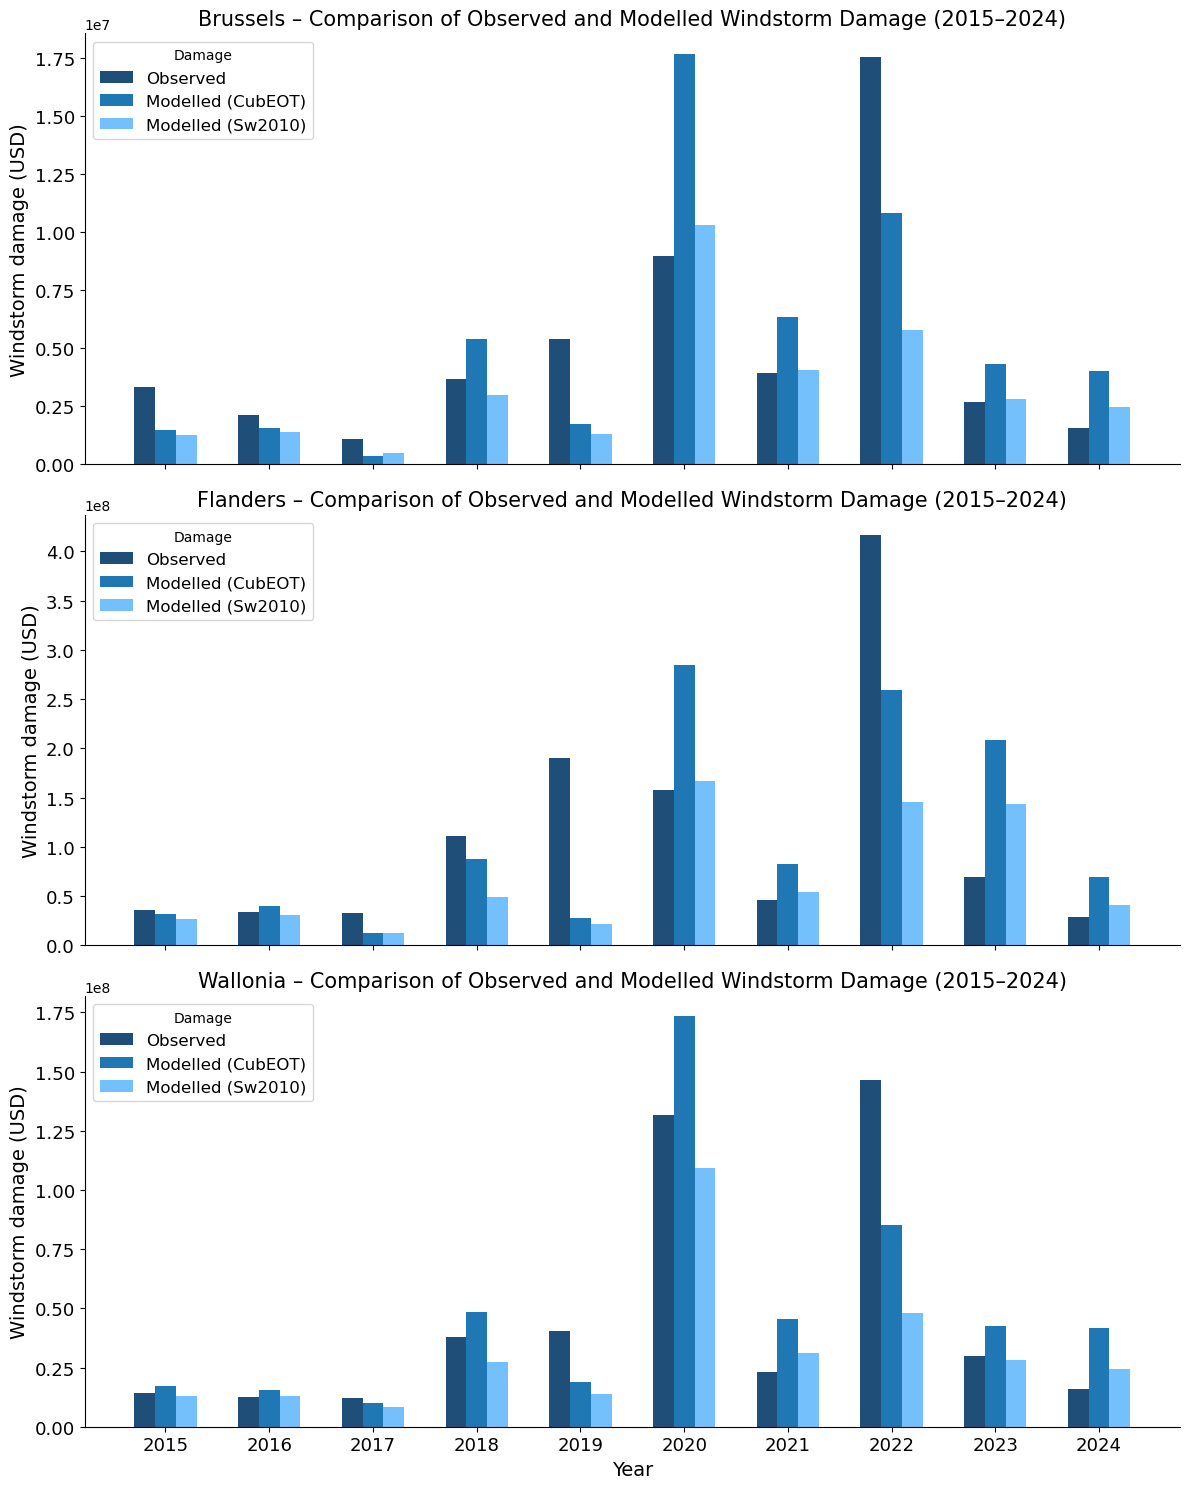

In [96]:
#Figure to compare observed and modelled values
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

years = list(range(2015, 2025))
gewesten = comparison_table.index

#Get impact functions
impf_list = sorted(list(set(
    col.split('_')[2] for col in comparison_table.columns if col.startswith("model_")
)))

#Make dataFrame
plot_data = []

for gewest in gewesten:
    for year in years:

        row = {
            "Year": year,
            "Gewest": gewest,
            "Observed": comparison_table.loc[gewest, f"obs_{year}"]
        }

        for impfname in impf_list:
            row[f"Model_{impfname}"] = comparison_table.loc[gewest, f"model_{year}_{impfname}"]

        plot_data.append(row)

plot_df = pd.DataFrame(plot_data)

#Make numeric
plot_df["Observed"] = pd.to_numeric(plot_df["Observed"])

for impfname in impf_list:
    plot_df[f"Model_{impfname}"] = pd.to_numeric(plot_df[f"Model_{impfname}"])


plot_df["Gewest"] = pd.Categorical(plot_df["Gewest"], categories=gewesten, ordered=True)

#Plotting
fig, axes = plt.subplots(
    nrows=len(gewesten),
    ncols=1,
    figsize=(12, 15),
    sharex=True
)

if len(gewesten) == 1:
    axes = [axes]

for ax, gewest in zip(axes, gewesten):

    df = plot_df[plot_df["Gewest"] == gewest]

    x = np.arange(len(years))
    width = 0.2  

    #Observed data
    ax.bar(
        x - width,
        df["Observed"],
        width,
        label="Observed",
        color=blue_dark
    )

    #Modelled data
    colors = [blue_light, blue_very_light]  

    for i, impfname in enumerate(impf_list):
        ax.bar(
            x + i * width,
            df[f"Model_{impfname}"],
            width,
            label=f"Model {impfname}",
            color=colors[i]
        )

    ax.set_ylabel("Windstorm damage (USD)", fontsize = 14)
    ax.set_title(f"{gewest} – Comparison of Observed and Modelled Windstorm Damage (2015–2024)", fontsize = 15)
    ax.set_xticks(x)
    ax.set_xticklabels(years)

    ax.legend(
        ["Observed", "Modelled (CubEOT)", "Modelled (Sw2010)"],
        title="Damage",
        loc="upper left",
        fontsize = 12
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis='both', labelsize=13)

plt.xlabel("Year", fontsize = 14)
plt.tight_layout()
plt.savefig("/Users/anne-sophiesimons/Documents/Data thesis/gewesten_obsVSmod", dpi=300)
plt.show()

### At provincial level

In [97]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np

os.environ["SHAPE_RESTORE_SHX"] = "YES"

#Load shapefile
provinces = gpd.read_file('/Users/anne-sophiesimons/Documents/Data thesis/gadm41_BEL_2.shp')
provinces = provinces.set_crs(epsg=4326)

#Table with impact per year and impact function
impact_all_years = pd.DataFrame()

years = list(range(2015, 2025))

#Loop over all years
for i, year in enumerate(years):

    print(f"Processing maps for {year}")

    #Loop over impact functions
    for impfname, imp in impacts[year].items():

        print(f"  Impact function: {impfname}")

        #Exposure
        points = exp_data[year].gdf.copy()
        points = points.set_crs(epsg=4326)

        #Add impact function
        points['impact'] = imp.eai_exp

        #Add coordinates
        points['longitude'] = points.geometry.x
        points['latitude'] = points.geometry.y

        #Spatial join
        points_with_polygon = gpd.sjoin(points, provinces, how='left', predicate='within')

        #Impact per provincie
        impact_by_polygon = (
            points_with_polygon
            .groupby('index_right')['impact']
            .sum()
            .reset_index()
        )

        #Merge with shapefile
        provinces_merged = provinces.merge(
            impact_by_polygon,
            left_index=True,
            right_on='index_right',
            how='left'
        )

        #Save in table
        impact_all_years[f'{year}_{impfname}'] = provinces_merged['impact']



#Formatting table
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 170)
pd.set_option('display.float_format', '{:.6e}'.format)

#Index names for provinces
names = {
    0: 'Brussels',
    1: 'Antwerp',
    2: 'Limburg',
    3: 'East Flanders',
    4: 'Flemish Brabant',
    5: 'West Flanders',
    6: 'Walloon Brabant',
    7: 'Hainaut',
    8: 'Liège',
    9: 'Luxembourg',
    10: 'Namur'
}

impact_all_years.index = impact_all_years.index.map(names)

print(impact_all_years)

Processing maps for 2015
  Impact function: Sw2010
  Impact function: CubEOT
Processing maps for 2016
  Impact function: Sw2010
  Impact function: CubEOT
Processing maps for 2017
  Impact function: Sw2010
  Impact function: CubEOT
Processing maps for 2018
  Impact function: Sw2010
  Impact function: CubEOT
Processing maps for 2019
  Impact function: Sw2010
  Impact function: CubEOT
Processing maps for 2020
  Impact function: Sw2010
  Impact function: CubEOT
Processing maps for 2021
  Impact function: Sw2010
  Impact function: CubEOT
Processing maps for 2022
  Impact function: Sw2010
  Impact function: CubEOT
Processing maps for 2023
  Impact function: Sw2010
  Impact function: CubEOT
Processing maps for 2024
  Impact function: Sw2010
  Impact function: CubEOT
                 2015_Sw2010  2015_CubEOT  2016_Sw2010  2016_CubEOT  2017_Sw2010  2017_CubEOT  2018_Sw2010  2018_CubEOT  2019_Sw2010  2019_CubEOT  2020_Sw2010  \
Brussels        1.254951e+06 1.493286e+06 1.396278e+06 1.560402e+06 

In [98]:
import pandas as pd

#Load Assuralia data at provincal level
Assuralia_per_provincie = pd.read_excel(
    '/Users/anne-sophiesimons/Documents/Data thesis/Schade per provincie.xlsx'
)

assuralia_long = Assuralia_per_provincie.melt(
    id_vars=['Jaar'],
    var_name='province',
    value_name='impact'
)

assuralia_table = assuralia_long.pivot(
    index='province',
    columns='Jaar',
    values='impact'
)

#Change column names
assuralia_table.columns = [f'impact_{year}' for year in assuralia_table.columns]

#Sort provinces
assuralia_table = assuralia_table.sort_index()

#Formatting scientific notation with 6 decimals
assuralia_table_formatted = assuralia_table.applymap(
    lambda x: f"{x:.6e}" if pd.notnull(x) else "NaN"
)

print(assuralia_table_formatted)

import pandas as pd

#Show all columns
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', 150)       
pd.set_option('display.float_format', '{:.6e}'.format)  

                  impact_2015   impact_2016   impact_2017   impact_2018   impact_2019   impact_2020   impact_2021   impact_2022   impact_2023   impact_2024
province                                                                                                                                                   
Antwerp          1.181010e+07  7.484862e+06  8.393370e+06  4.986251e+07  5.564058e+07  4.105765e+07  1.303618e+07  8.407510e+07  1.364176e+07  7.419731e+06
Brussels         3.337959e+06  2.099850e+06  1.080671e+06  3.657640e+06  5.380766e+06  8.977559e+06  3.923544e+06  1.752121e+07  2.663364e+06  1.570886e+06
East Flanders    6.284672e+06  8.031408e+06  8.179520e+06  1.643863e+07  5.721445e+07  4.039920e+07  8.855719e+06  1.087429e+08  2.030494e+07  5.073246e+06
Flemish Brabant  4.194658e+06  5.390345e+06  3.536093e+06  1.196670e+07  2.244757e+07  3.155976e+07  7.129676e+06  4.659400e+07  1.049785e+07  4.693951e+06
Hainaut          6.467346e+06  5.585148e+06  5.320191e+06  1.261

In [99]:
import pandas as pd

#Correct index
impact_model = impact_all_years.copy()
impact_model.index.name = "province"

impact_obs = assuralia_table_formatted.copy()
impact_obs.index.name = "province"

#Empty table
comparison_table = pd.DataFrame(index=impact_model.index)

years = range(2015, 2025)

#Get impact functions
impf_list = sorted(list(set(
    col.split('_')[1] for col in impact_model.columns
)))

#Loop over years and impact functions
for year in years:
    for impfname in impf_list:

        col_name = f'{year}_{impfname}'

        #Modelled data
        if col_name in impact_model.columns:
            comparison_table[f'model_{col_name}'] = impact_model[col_name]
        else:
            comparison_table[f'model_{col_name}'] = None

    #Observed data
    if f'impact_{year}' in impact_obs.columns:
        comparison_table[f'obs_{year}'] = impact_obs[f'impact_{year}']
    else:
        comparison_table[f'obs_{year}'] = None

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 170)
pd.set_option('display.float_format', '{:.1f}'.format)

print(comparison_table)

                 model_2015_CubEOT  model_2015_Sw2010      obs_2015  model_2016_CubEOT  model_2016_Sw2010      obs_2016  model_2017_CubEOT  model_2017_Sw2010  \
province                                                                                                                                                        
Brussels                 1493285.9          1254950.9  3.337959e+06          1560402.4          1396278.2  2.099850e+06           358044.4           497091.2   
Antwerp                  8344213.7          6585622.8  1.181010e+07          6937615.5          5729570.5  7.484862e+06          4902282.2          3991712.9   
Limburg                  5706809.0          4189507.2  4.688267e+06          5467394.0          3464145.3  2.205534e+06          1893812.8          1752890.4   
East Flanders            6878362.6          6106740.5  6.284672e+06          8501292.4          6941846.2  8.031408e+06          2159412.6          2525022.0   
Flemish Brabant          4974425.0

In [100]:
import pandas as pd

#Prepare data
impact_model = impact_all_years.copy()
impact_model.index.name = "province"

impact_obs = assuralia_table_formatted.copy()
impact_obs.index.name = "province"

years = range(2015, 2025)

#Get impact function
impf_list = sorted(list(set(
    col.split('_')[1] for col in impact_model.columns
)))


#Build table
comparison_table = pd.DataFrame(index=impact_model.index)

for year in years:
    for impfname in impf_list:

        col_name = f"{year}_{impfname}"

        if col_name in impact_model.columns:
            comparison_table[f"model_{col_name}"] = impact_model[col_name]
        else:
            comparison_table[f"model_{col_name}"] = None

    # observaties
    if f"impact_{year}" in impact_obs.columns:
        comparison_table[f"obs_{year}"] = impact_obs[f"impact_{year}"]
    else:
        comparison_table[f"obs_{year}"] = None

#Make numeric
comparison_table = comparison_table.apply(pd.to_numeric, errors="coerce")

#Change to millions
comparison_table = comparison_table / 1e6

#Round
comparison_table = comparison_table.round(1)

#Make long format
rows = []

for province in comparison_table.index:
    for year in years:

        row = {
            "Province": province,
            "Year": year,
            "CubEOT": None,
            "Sw2010": None,
            "Observed": None
        }

        # model
        for impf in ["CubEOT", "Sw2010"]:
            col = f"model_{year}_{impf}"
            if col in comparison_table.columns:
                row[impf] = comparison_table.loc[province, col]

        # observaties
        obs_col = f"obs_{year}"
        if obs_col in comparison_table.columns:
            row["Observed"] = comparison_table.loc[province, obs_col]

        rows.append(row)

long_table_prov = pd.DataFrame(rows)

#Clean and round
long_table_prov = long_table_prov.apply(pd.to_numeric, errors="ignore")

long_table_prov[["CubEOT", "Sw2010", "Observed"]] = long_table_prov[
    ["CubEOT", "Sw2010", "Observed"]
].round(1)

#Print without index
print(long_table_prov.to_string(index=False))

print(long_table_prov.to_string(index=False))

       Province  Year  CubEOT  Sw2010  Observed
       Brussels  2015     1.5     1.3       3.3
       Brussels  2016     1.6     1.4       2.1
       Brussels  2017     0.4     0.5       1.1
       Brussels  2018     5.4     3.0       3.7
       Brussels  2019     1.7     1.3       5.4
       Brussels  2020    17.7    10.3       9.0
       Brussels  2021     6.3     4.1       3.9
       Brussels  2022    10.8     5.8      17.5
       Brussels  2023     4.3     2.8       2.7
       Brussels  2024     4.0     2.4       1.6
        Antwerp  2015     8.3     6.6      11.8
        Antwerp  2016     6.9     5.7       7.5
        Antwerp  2017     4.9     4.0       8.4
        Antwerp  2018    22.2    12.7      49.9
        Antwerp  2019     4.2     4.0      55.6
        Antwerp  2020    64.8    37.5      41.1
        Antwerp  2021    26.4    15.8      13.0
        Antwerp  2022    57.8    29.9      84.1
        Antwerp  2023    29.7    17.6      13.6
        Antwerp  2024    13.9     8.7   

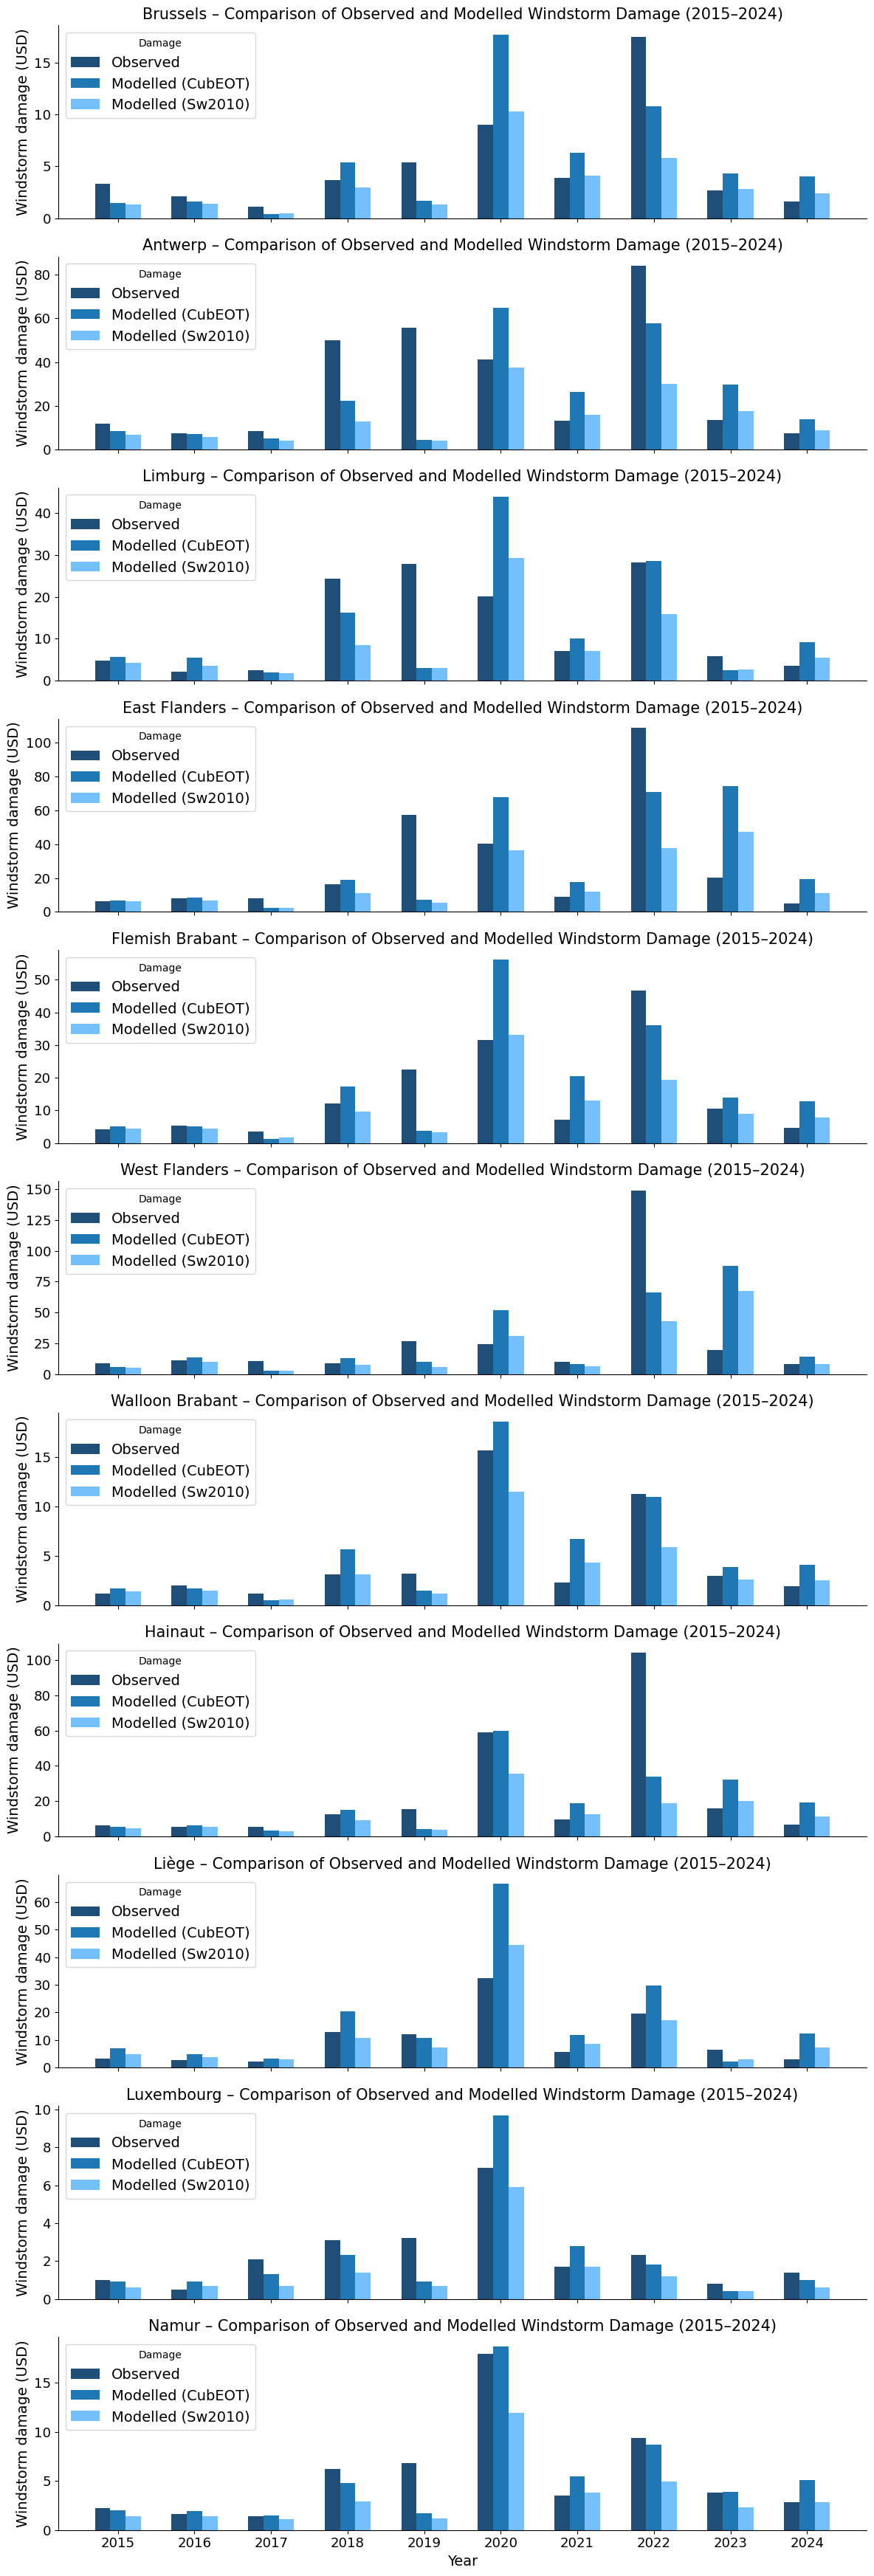

In [102]:
#Figure: observed vs modelld data at provinial level
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

years = list(range(2015, 2025))
provincies = comparison_table.index

#Get impact functions
impf_list = sorted(list(set(
    col.split('_')[2] for col in comparison_table.columns if col.startswith("model_")
)))

#Make dataFrame
plot_data = []

for provincie in provincies:
    for year in years:

        row = {
            "Year": year,
            "Provincie": provincie,
            "Observed": comparison_table.loc[provincie, f"obs_{year}"]
        }

        for impfname in impf_list:
            row[f"Model_{impfname}"] = comparison_table.loc[provincie, f"model_{year}_{impfname}"]

        plot_data.append(row)

plot_df = pd.DataFrame(plot_data)

#Make numeric
plot_df["Observed"] = pd.to_numeric(plot_df["Observed"])

for impfname in impf_list:
    plot_df[f"Model_{impfname}"] = pd.to_numeric(plot_df[f"Model_{impfname}"])


plot_df["Provincie"] = pd.Categorical(plot_df["Provincie"], categories=provincies, ordered=True)

#Plotting
fig, axes = plt.subplots(
    nrows=len(provincies),
    ncols=1,
    figsize=(12, 35),
    sharex=True
)

if len(provincies) == 1:
    axes = [axes]

for ax, provincie in zip(axes, provincies):

    df = plot_df[plot_df["Provincie"] == provincie]

    x = np.arange(len(years))
    width = 0.2 

    #Observed data
    ax.bar(
        x - width,
        df["Observed"],
        width,
        label="Observed",
        color=blue_dark
    )

    #Modelled data
    colors = [blue_light, blue_very_light] 

    for i, impfname in enumerate(impf_list):
        ax.bar(
            x + i * width,
            df[f"Model_{impfname}"],
            width,
            label=f"Model {impfname}",
            color=colors[i]
        )

    ax.set_ylabel("Windstorm damage (USD)", fontsize = 14)
    ax.set_title(f"{provincie} – Comparison of Observed and Modelled Windstorm Damage (2015–2024)", fontsize = 15)
    ax.set_xticks(x)
    ax.set_xticklabels(years)

    ax.legend(
        ["Observed", "Modelled (CubEOT)", "Modelled (Sw2010)"],
        title="Damage",
        loc="upper left",
        fontsize = 14
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis='both', labelsize=13)

plt.xlabel("Year", fontsize = 14)
plt.tight_layout()
plt.savefig("/Users/anne-sophiesimons/Documents/Data thesis/provincies_obsVSmod", dpi=300)
plt.show()

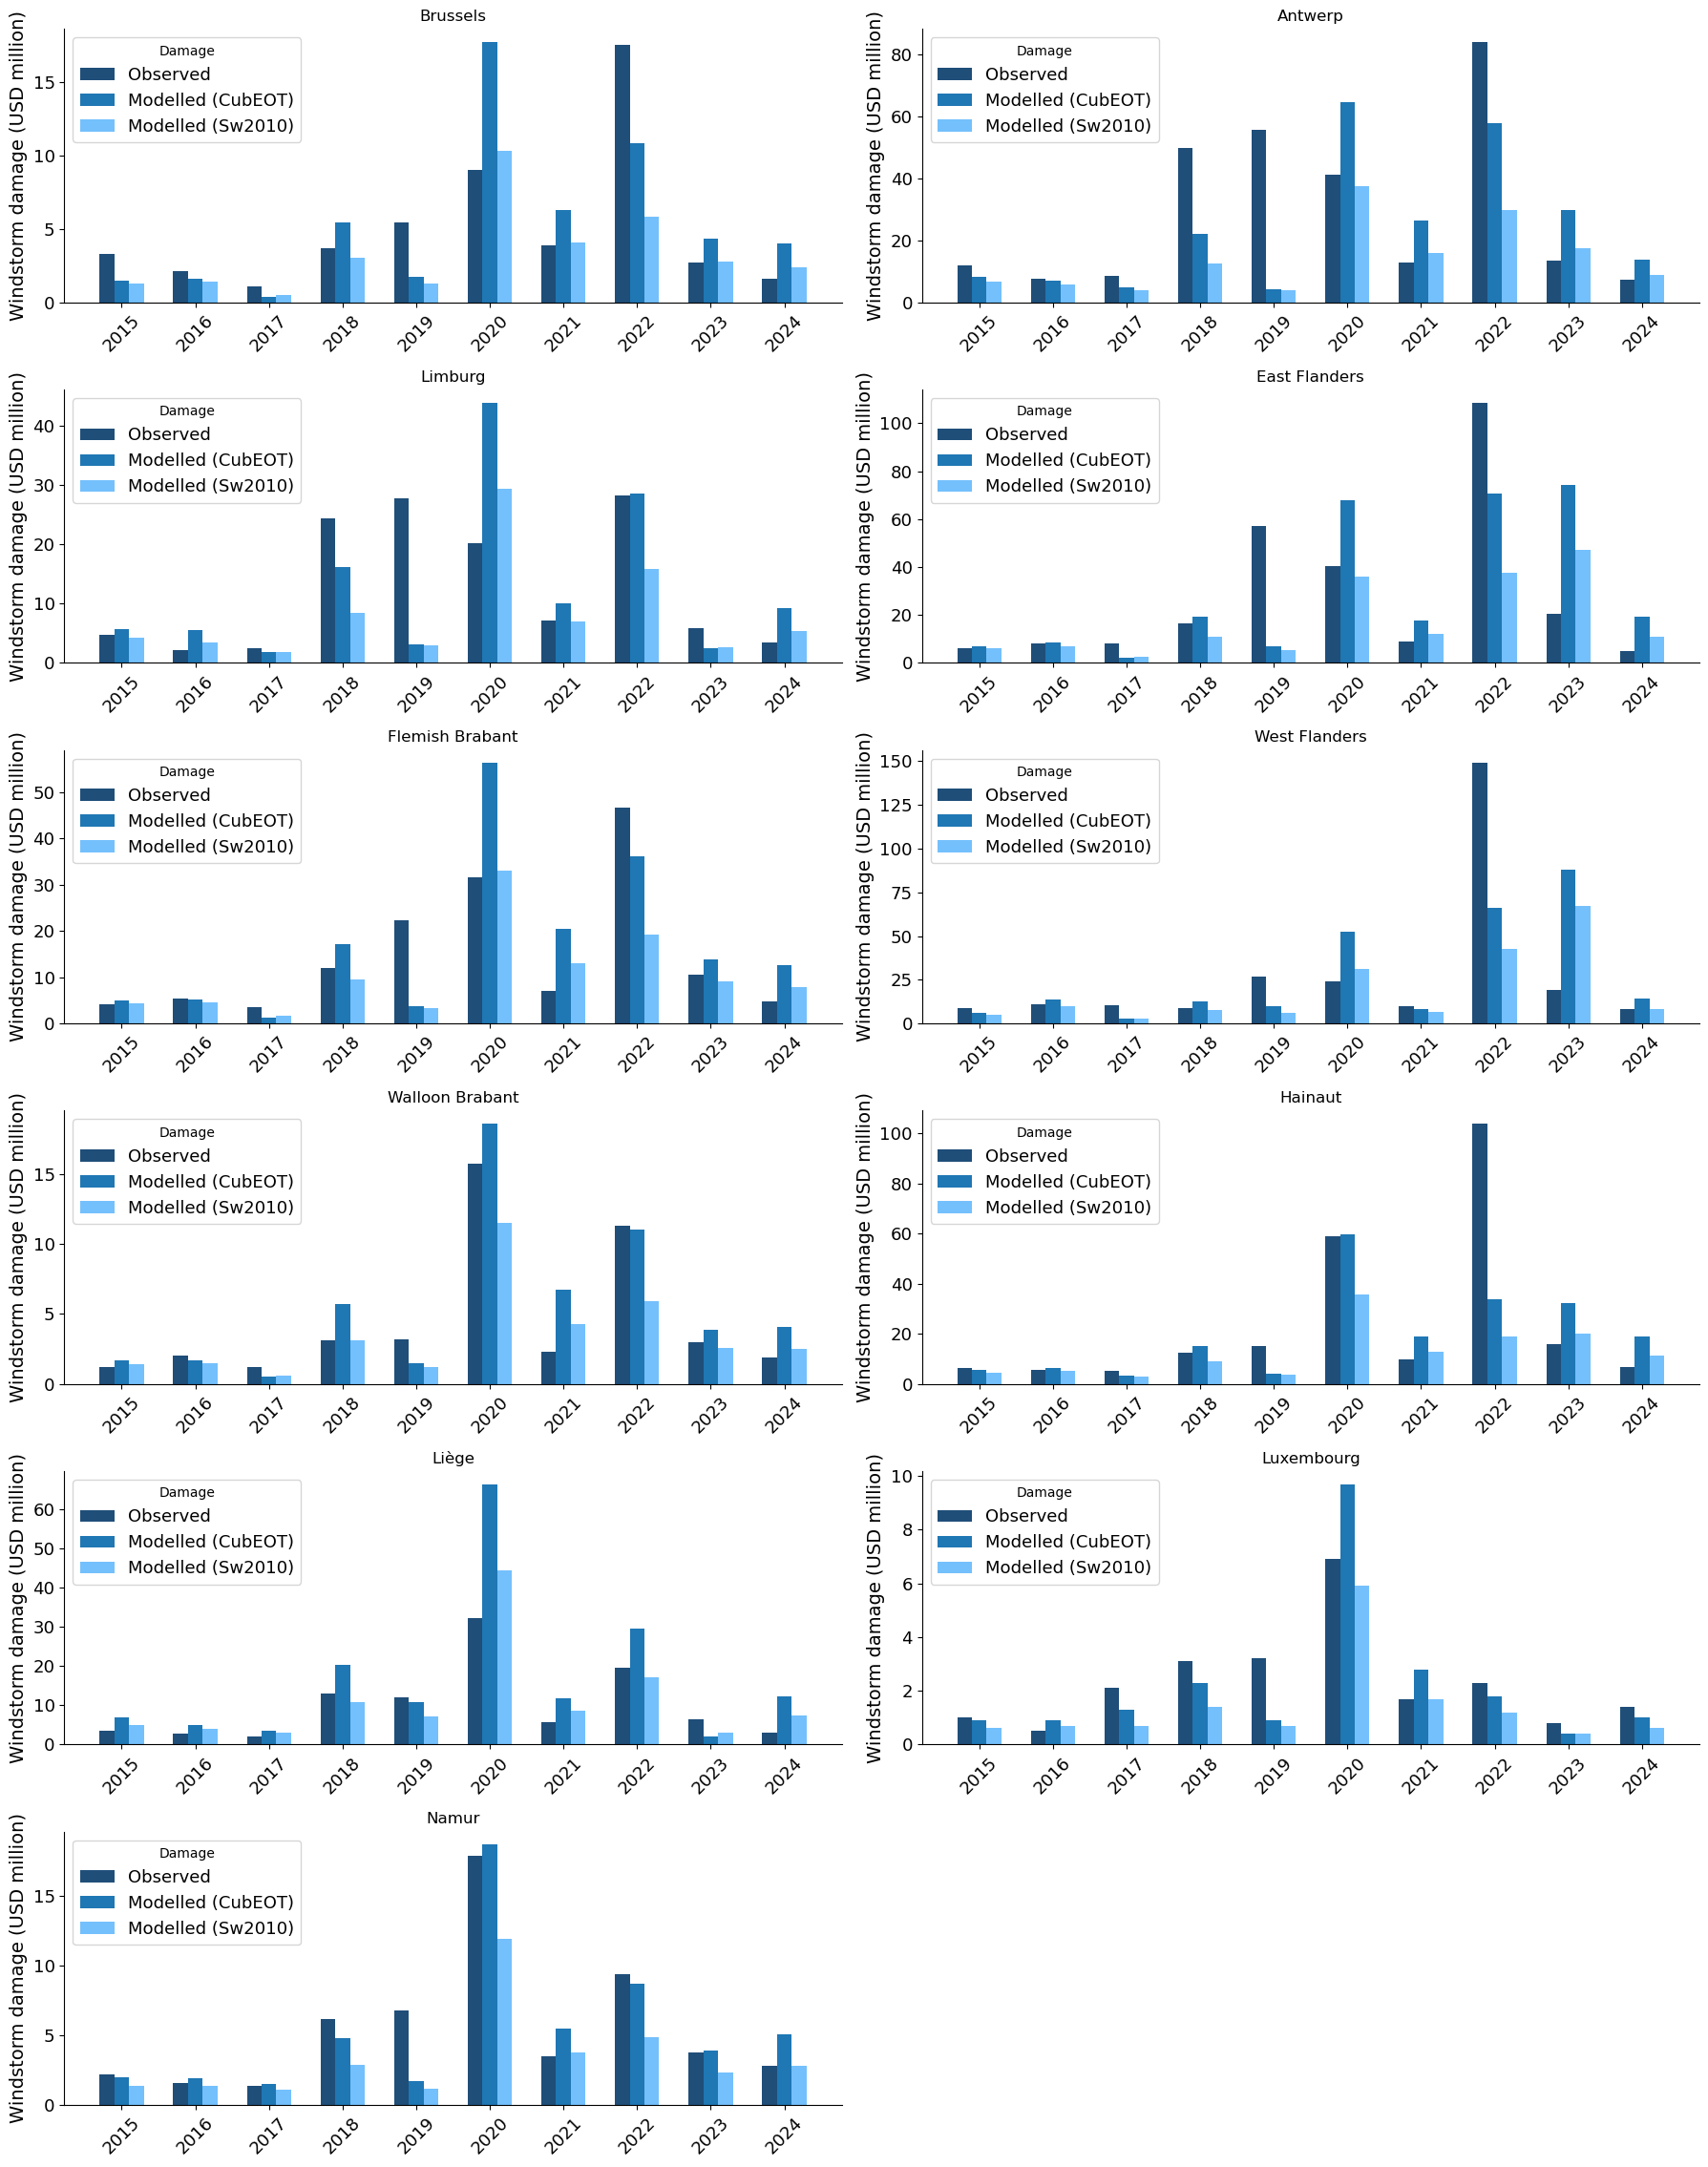

In [104]:
#Same figure but other representation
import math

ncols = 2
nrows = math.ceil(len(provincies) / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(18, 4 * nrows),
    sharex=True
)

axes = axes.flatten()

for i, provincie in enumerate(provincies):

    ax = axes[i]
    df = plot_df[plot_df["Provincie"] == provincie]

    x = np.arange(len(years))
    width = 0.2

    ax.bar(
        x - width,
        df["Observed"],
        width,
        label="Observed",
        color=blue_dark
    )

    colors = [blue_light, blue_very_light]

    for j, impfname in enumerate(impf_list):
        ax.bar(
            x + j * width,
            df[f"Model_{impfname}"],
            width,
            label=f"Model {impfname}",
            color=colors[j]
        )

    ax.set_title(f"{provincie}")
    ax.set_xticks(x)
    ax.set_xticklabels(years, rotation=45)

    ax.set_ylabel("Windstorm damage (USD million)", fontsize = 14)

    ax.legend(
        ["Observed", "Modelled (CubEOT)", "Modelled (Sw2010)"],
        title="Damage",
        loc="upper left",
        fontsize = 13
    )

for ax in axes:
    ax.tick_params(axis='x', labelbottom=True)    

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis='both', labelsize=13)

for k in range(len(provincies), len(axes)):
    fig.delaxes(axes[k])


plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("/Users/anne-sophiesimons/Documents/Data thesis/provincies_obsVSmod_grid", dpi=300)
plt.show()

In [73]:
#Metrics at provincial level
import numpy as np
import pandas as pd

years = range(2015, 2025)

#Get impact function
impf_list = sorted(list(set(
    col.split('_')[2] for col in comparison_table.columns if col.startswith("model_")
)))

results = []

for region in comparison_table.index:

    for impfname in impf_list:

        #Modelled values
        model = pd.to_numeric(
            [comparison_table.loc[region, f"model_{year}_{impfname}"] for year in years],
            errors="coerce"
        )

        #Observed values
        obs = pd.to_numeric(
            [comparison_table.loc[region, f"obs_{year}"] for year in years],
            errors="coerce"
        )

        model = np.array(model, dtype=float)
        obs = np.array(obs, dtype=float)

        mask = ~np.isnan(model) & ~np.isnan(obs) & (obs != 0)

        if np.sum(mask) == 0:
            continue

        mae = np.mean(np.abs(model[mask] - obs[mask]))
        rmse = np.sqrt(np.mean((model[mask] - obs[mask])**2))
        bias = np.mean(model[mask] - obs[mask])
        mape = np.mean(np.abs((model[mask] - obs[mask]) / obs[mask])) * 100

        #Compute correlation
        if np.std(model[mask]) == 0 or np.std(obs[mask]) == 0:
            corr = np.nan
        else:
            corr = np.corrcoef(model[mask], obs[mask])[0, 1]

        results.append({
            "Provincie": region,
            "impact_function": impfname,
            "MAE": mae,
            "RMSE": rmse,
            "Bias": bias,
            "MAPE (%)": mape,
            "Correlation r": corr,
            "R²": corr**2 if not np.isnan(corr) else np.nan
        })

results_df = pd.DataFrame(results).set_index(["Provincie", "impact_function"])

print(results_df)

                                 MAE  RMSE  Bias  MAPE (%)  Correlation r  R²
Provincie       impact_function                                              
Brussels        CubEOT           3.0   3.9   0.3      66.2            0.7 0.5
                Sw2010           2.2   4.0  -1.7      38.3            0.6 0.4
Antwerp         CubEOT          17.3  22.7  -5.3      62.6            0.6 0.3
                Sw2010          16.6  26.6 -15.0      43.0            0.5 0.3
Limburg         CubEOT           7.4  11.4   0.0      70.0            0.5 0.3
                Sw2010           7.0  10.6  -4.5      45.2            0.5 0.2
East Flanders   CubEOT          20.3  28.2   1.4      94.3            0.6 0.3
                Sw2010          17.6  29.3 -10.3      57.2            0.5 0.2
Flemish Brabant CubEOT           8.7  11.7   2.4      70.6            0.7 0.5
                Sw2010           6.4  10.8  -4.2      40.5            0.7 0.5
West Flanders   CubEOT          22.2  35.7  -0.3      86.2      

In [74]:
#Metrics at national level
import numpy as np

years = list(range(2015, 2025))

impf_list = sorted(list(set(
    col.split('_')[2] for col in comparison_table.columns if col.startswith("model_")
)))

results = []

for impfname in impf_list:

    model_all = []
    obs_all = []

    for region in comparison_table.index:
        for year in years:

            model_val = comparison_table.loc[region, f"model_{year}_{impfname}"]
            obs_val = comparison_table.loc[region, f"obs_{year}"]

            model_all.append(model_val)
            obs_all.append(obs_val)

    model_all = np.array(model_all, dtype=float)
    obs_all = np.array(obs_all, dtype=float)

    mask = ~np.isnan(model_all) & ~np.isnan(obs_all) & (obs_all != 0)

    if np.sum(mask) == 0:
        continue

    mae_total = np.mean(np.abs(model_all[mask] - obs_all[mask]))
    rmse_total = np.sqrt(np.mean((model_all[mask] - obs_all[mask])**2))
    bias_total = np.mean(model_all[mask] - obs_all[mask])
    mape_total = np.mean(np.abs((model_all[mask] - obs_all[mask]) / obs_all[mask])) * 100

    #Correlation
    if np.std(model_all[mask]) == 0 or np.std(obs_all[mask]) == 0:
        corr_total = np.nan
    else:
        corr_total = np.corrcoef(model_all[mask], obs_all[mask])[0,1]

    results.append({
        "impact_function": impfname,
        "MAE": mae_total,
        "RMSE": rmse_total,
        "Bias": bias_total,
        "MAPE (%)": mape_total,
        "Correlation r": corr_total,
        "R²": corr_total**2 if not np.isnan(corr_total) else np.nan
    })

results_df = pd.DataFrame(results).set_index("impact_function")

print(results_df)

                 MAE  RMSE  Bias  MAPE (%)  Correlation r  R²
impact_function                                              
CubEOT           9.4  18.0   0.2      67.3            0.6 0.4
Sw2010           8.4  19.2  -5.4      44.6            0.6 0.4
